# 2 · Preprocesamiento y modelado con scikit-learn (seis modelos)

**Objetivo del capítulo.** Se prepara la tabla de modelado, se lee la **partición común** 80/20 (la misma
que usará PySpark), se entrenan **seis modelos** con `GridSearchCV` **sin `Pipeline`**
(`scoring="roc_auc"`, `n_jobs=-1`, **3 pliegues**), se evalúan en el conjunto de
prueba y se guardan las **puntuaciones continuas** del conjunto de prueba para la prueba de DeLong del capítulo 5.

| Decisión | Motivo |
|---|---|
| Partición común (80/20, estratificada, semilla 42) **leída de un archivo** | Ambos entornos deben usar exactamente los mismos préstamos: la prueba de DeLong compara AUC calculados sobre las mismas observaciones |
| 3 pliegues **fijos y estratificados**, guardados en el mismo archivo (`fold`) | scikit-learn y el `CrossValidator` de Spark validan sobre **los mismos** pliegues (`foldCol`) |
| `GridSearchCV(scoring="roc_auc")` | El `scoring` por defecto es la exactitud, engañosa con un 80 % de clase mayoritaria |
| Imputación sin parámetros aprendidos (centinela −1); codificación y escalado sí los aprenden | El preprocesamiento se ajusta **antes** de la validación cruzada; ver la comprobación de la sección 2.6 |
| Umbral elegido con predicciones **fuera de pliegue** del entrenamiento | Elegirlo con el conjunto de prueba lo contaminaría |
| El conjunto de prueba no interviene en ninguna decisión de modelado | Elegir variables, hiperparámetros o umbral mirando el conjunto de prueba produce estimaciones optimistas |

In [1]:
import gc
import json
import os
import platform
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, average_precision_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_models as lm  # noqa: E402
from src import lc_utils as lc  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, message=".*n_jobs.*")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS, DATA_DIR = Path("../resultados"), Path("../data")
RESULTS.mkdir(exist_ok=True)
(DATA_DIR / "models").mkdir(parents=True, exist_ok=True)
N_CPU = os.cpu_count()
TIMES = {}          # tiempos (segundos) -> se guardan para la comparación con PySpark
print(f"Python {platform.python_version()} · scikit-learn {sklearn.__version__} · pandas {pd.__version__} "
      f"· {N_CPU} hilos lógicos · RAM {psutil.virtual_memory().total / 1e9:.1f} GB")

Python 3.10.21 · scikit-learn 1.3.0 · pandas 2.1.0 · 12 hilos lógicos · RAM 16.9 GB


## 2.1 Carga y tabla de modelado

Se lee el CSV **completo** (todas las filas; solo se eligen las 24 columnas necesarias para no
gastar memoria) y se construye la tabla con solo los préstamos de desenlace conocido.

In [2]:
t0 = time.time()
raw = lc.load_raw(usecols=lc.RAW_COLUMNS)
TIMES["carga_csv"] = time.time() - t0
print(f"Carga del CSV: {raw.shape[0]:,} filas × {raw.shape[1]} columnas en {TIMES['carga_csv']:.1f} s")

t0 = time.time()
m = lc.build_model_frame(raw)
TIMES["features"] = time.time() - t0
del raw
gc.collect()
print(f"Tabla de modelado: {m.shape[0]:,} filas · features en {TIMES['features']:.1f} s")
print(f"Tasa de incumplimiento: {m['default'].mean():.4%}")

Carga del CSV: 2,260,701 filas × 24 columnas en 26.9 s


Tabla de modelado: 1,345,310 filas · features en 10.8 s
Tasa de incumplimiento: 19.9626%


## 2.2 Partición común y pliegues fijos

La partición **ya se hizo en el capítulo de EDA, antes de explorar nada**, y se guardó en
`data/split_ids.parquet` con las columnas `id` y `split` (`train` / `test`), más `fold` (pliegue
0, 1 o 2 de las filas de entrenamiento, estratificado por `default`). Aquí se **lee** y, como
comprobación de reproducibilidad, se vuelve a calcular y se verifica que sea idéntica. El capítulo de
PySpark lee **ese mismo archivo**.

In [3]:
split = pd.read_parquet(DATA_DIR / "split_ids.parquet")
recalculada = lc.make_split(m)
assert split["id"].equals(recalculada["id"]) and (split["split"] == recalculada["split"]).all() \
    and (split["fold"] == recalculada["fold"]).all(), "La partición guardada no coincide con la recalculada"
print("Partición guardada = partición recalculada: OK (misma semilla, mismos datos)")
es_test = (split["split"] == "test").to_numpy()
idx_train, idx_test = np.flatnonzero(~es_test), np.flatnonzero(es_test)
train, test = m.iloc[idx_train].reset_index(drop=True), m.iloc[idx_test].reset_index(drop=True)
y_train, y_test = train["default"].to_numpy(), test["default"].to_numpy()
fold = split.loc[~es_test, "fold"].to_numpy()
FOLDS = [(np.flatnonzero(fold != k), np.flatnonzero(fold == k)) for k in range(3)]     # (entrenar, validar)

resumen_split = pd.DataFrame({
    "filas": [len(train), len(test)],
    "% del total": [100 * len(train) / len(m), 100 * len(test) / len(m)],
    "tasa de default": [train["default"].mean(), test["default"].mean()]}, index=["entrenamiento", "prueba"])
display(resumen_split)
display(pd.DataFrame({"filas de validación": [len(v) for _, v in FOLDS],
                      "tasa de default": [y_train[v].mean() for _, v in FOLDS]},
                     index=[f"pliegue {k}" for k in range(3)]))

Partición guardada = partición recalculada: OK (misma semilla, mismos datos)


,filas,% del total,tasa de default
entrenamiento,1076248,80.0000,0.1996
prueba,269062,20.0000,0.1996


,filas de validación,tasa de default
pliegue 0,358750,0.1996
pliegue 1,358749,0.1996
pliegue 2,358749,0.1996


## 2.3 Preprocesamiento

* **Numéricas (17):** los nulos se rellenan con el centinela **−1** (sin parámetros aprendidos).
* **Categóricas (4):** *One-Hot*; las categorías con menos del 1 % **del entrenamiento** se
  agrupan como "infrecuente" (las categorías nuevas del conjunto de prueba también).
* **Escalado (`StandardScaler`):** solo para la **regresión logística** y la **SVM lineal**, que
  son sensibles a la escala. Los árboles, el *gradient boosting* y Naive Bayes trabajan con las
  variables sin escalar. El escalador se **ajusta solo con el entrenamiento**.

In [4]:
t0 = time.time()
prep = lc.make_preprocessor()
X_train = prep.fit_transform(train[lc.FEATURES]).astype(np.float32)
X_test = prep.transform(test[lc.FEATURES]).astype(np.float32)
scaler = StandardScaler().fit(X_train)
Xs_train, Xs_test = scaler.transform(X_train).astype(np.float32), scaler.transform(X_test).astype(np.float32)
TIMES["preprocesamiento"] = time.time() - t0
feature_names = prep.get_feature_names_out()
print(f"X_train: {X_train.shape} · X_test: {X_test.shape} · dtype {X_train.dtype} "
      f"· {X_train.nbytes / 1e9:.2f} GB · preprocesamiento en {TIMES['preprocesamiento']:.1f} s")

enc = prep.named_transformers_["cat"]
infrecuentes = {c: sorted(i.tolist()) if i is not None else []
                for c, i in zip(lc.CATEGORICAL, enc.infrequent_categories_)}
(RESULTS / "categorias_infrecuentes.json").write_text(json.dumps(infrecuentes, ensure_ascii=False, indent=1), encoding="utf-8")
(RESULTS / "paridad_features.json").write_text(
    json.dumps({"medias": {c: float(m[c].mean()) for c in lc.NUMERIC}}, indent=1), encoding="utf-8")

X_train: (1076248, 62) · X_test: (269062, 62) · dtype float32 · 0.27 GB · preprocesamiento en 5.4 s


629

## 2.4 Los seis modelos y sus espacios de búsqueda

Son **los mismos** que en PySpark (Tabla 2.1). Equivalencias que conviene tener presentes (se
retoman en la discusión final):

* **Regularización L2** en ambos entornos. En la regresión logística y la SVM lineal, PySpark usa
  `regParam ∈ {1e-6, 1e-5, 1e-4}` y scikit-learn `C = 1 / (regParam × n)` con `n` = filas de
  entrenamiento. La relación es **aproximada**: `C` pondera la *suma* de las pérdidas y `regParam`
  su *promedio*.
* **`LinearSVC(loss="hinge")`**: el valor por defecto de scikit-learn es *squared hinge*; el de PySpark
  minimiza *hinge*, así que se fija `loss="hinge"`.
* **Árboles:** scikit-learn evalúa cortes **exactos**; PySpark discretiza cada variable continua en
  `maxBins = 32` intervalos.
* **Naive Bayes gaussiano** en ambos, sin búsqueda de hiperparámetros.

**Decisión sobre el gradient boosting.** `GradientBoostingClassifier` es secuencial (no usa varios
hilos dentro de un ajuste) y con 1.08 millones de filas es el modelo más lento de este capítulo. Si su
costo resultara prohibitivo, la alternativa natural es `HistGradientBoostingClassifier`. Se fijó de
antemano un presupuesto de cómputo de 3 horas para la malla completa (12 ajustes) más el reajuste, y se
decide con una **medición** corta (10 árboles, profundidad 5, 100 000 filas), extrapolada al tamaño real
de un ajuste (100 árboles con las filas de dos pliegues).

In [5]:
N_TRAIN = len(y_train)
_gb = lm.sk_specs(N_TRAIN)["GB"][0]
_gb.set_params(n_estimators=10, max_depth=5)
_k = 100_000
t0 = time.time()
_gb.fit(X_train[:_k], y_train[:_k])
_t10 = time.time() - t0
_fila_pliegue = 2 * N_TRAIN // 3
_por_ajuste = _t10 / 10 * 100 * _fila_pliegue / _k          # 100 árboles con las filas de un pliegue de entrenamiento
_estimado = (12 / N_CPU * 0.6 + 1) * _por_ajuste * 1.5     # 12 ajustes en paralelo (aprox.) + reajuste con todo el train
GB_HIST = bool(_estimado > 3 * 3600)
print(f"10 árboles (prof. 5) con {_k:,} filas: {_t10:.1f} s → un ajuste de 100 árboles con {_fila_pliegue:,} filas ≈ "
      f"{_por_ajuste / 60:.1f} min · costo estimado de malla + reajuste ≈ {_estimado / 60:.0f} min")
print("Decisión:", "HistGradientBoostingClassifier (costo prohibitivo)" if GB_HIST else "GradientBoostingClassifier (costo aceptable)")
del _gb

10 árboles (prof. 5) con 100,000 filas: 10.3 s → un ajuste de 100 árboles con 717,498 filas ≈ 12.3 min · costo estimado de malla + reajuste ≈ 29 min
Decisión: GradientBoostingClassifier (costo aceptable)


In [6]:
specs = lm.sk_specs(N_TRAIN, gb_hist=GB_HIST)
tabla = pd.DataFrame([{"modelo": lm.NOMBRES[k], "estimador": type(e).__name__,
                       "espacio de búsqueda": json.dumps({a: [round(v, 5) if isinstance(v, float) else v for v in vals]
                                                          for a, vals in g.items()}) or "—",
                       "combinaciones": int(np.prod([len(v) for v in g.values()])) if g else 1,
                       "datos": "escalados" if lm.USA_ESCALADO.get(k) else "sin escalar"}
                      for k, (e, g, _) in specs.items()])
display(tabla)
print(f"n de entrenamiento = {N_TRAIN:,} → C = " + ", ".join(f"{lm.c_from_reg(r, N_TRAIN):.5f}" for r in lm.REG_PARAMS)
      + " para regParam = " + ", ".join(f"{r:g}" for r in lm.REG_PARAMS))
print(f"Total de ajustes con 3 pliegues: {sum((int(np.prod([len(v) for v in g.values()])) if g else 1) * 3 for _, g, _ in specs.values())} "
      "+ un reajuste final por modelo")

,modelo,estimador,espacio de búsqueda,combinaciones,datos
0,Regresión logística,LogisticRegression,"{""C"": [0.92915, 0.09292, 0.00929]}",3,escalados
1,Árbol de decisión,DecisionTreeClassifier,"{""max_depth"": [5, 10, 15]}",3,sin escalar
2,Bosque aleatorio,RandomForestClassifier,"{""n_estimators"": [10, 50, 100], ""max_depth"": [...",9,sin escalar
3,Gradient boosting,GradientBoostingClassifier,"{""n_estimators"": [50, 100], ""max_depth"": [3, 5]}",4,sin escalar
4,SVM lineal,LinearSVC,"{""C"": [0.92915, 0.09292, 0.00929]}",3,escalados
5,Naive Bayes,GaussianNB,{},1,sin escalar


n de entrenamiento = 1,076,248 → C = 0.92915, 0.09292, 0.00929 para regParam = 1e-06, 1e-05, 0.0001
Total de ajustes con 3 pliegues: 69 + un reajuste final por modelo


## 2.5 Entrenamiento con validación cruzada (los seis modelos)

Para cada modelo: `GridSearchCV` **sin `Pipeline`**, con los 3 pliegues fijos, `scoring="roc_auc"`,
`n_jobs=-1` (los ajustes de la malla se reparten entre los hilos) y `refit=True` (el mejor modelo se
reajusta con todo el entrenamiento). **El tiempo de entrenamiento incluye la validación cruzada y el
reajuste.** Después:

1. se mide el tiempo de **predicción** sobre el conjunto de prueba y se guarda la **puntuación continua**
   (`predict_proba[:, 1]`; en `LinearSVC`, `decision_function`);
2. se calculan puntuaciones **fuera de pliegue** del entrenamiento (`cross_val_predict` con los mismos
   pliegues) para elegir el umbral sin usar el conjunto de prueba.


In [7]:
def clone_best(est):
    from sklearn.base import clone
    return clone(est)


def entrenar(clave: str) -> dict:
    est, grid, tipo = specs[clave]
    esc = lm.USA_ESCALADO.get(clave, False)
    Xtr, Xte = (Xs_train, Xs_test) if esc else (X_train, X_test)
    r = {"clave": clave, "modelo": lm.NOMBRES[clave], "escalado": esc, "tipo_puntuacion": tipo}
    t0 = time.time()
    if grid:
        gs = GridSearchCV(est, grid, cv=FOLDS, scoring="roc_auc", n_jobs=-1, refit=True, return_train_score=True)
        gs.fit(Xtr, y_train)
        best, r["mejores_hiperparametros"] = gs.best_estimator_, {k: float(v) if isinstance(v, (float, np.floating)) else int(v)
                                                                   for k, v in gs.best_params_.items()}
        r["auc_cv"], r["auc_cv_sd"] = float(gs.best_score_), float(gs.cv_results_["std_test_score"][gs.best_index_])
        cvres = pd.DataFrame(gs.cv_results_)
        cvres = cvres[[c for c in cvres.columns if c.startswith("param_") or c in
                       ("mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time", "rank_test_score")]]
        cvres.to_csv(RESULTS / f"sk_cv_{clave}.csv", index=False)
        r["auc_train_cv_mean"] = float(gs.cv_results_["mean_train_score"][gs.best_index_])
    else:                                                     # Naive Bayes: sin búsqueda de hiperparámetros
        aucs = cross_val_score(est, Xtr, y_train, cv=FOLDS, scoring="roc_auc")
        best = est.fit(Xtr, y_train)
        r["mejores_hiperparametros"], r["auc_cv"], r["auc_cv_sd"] = {}, float(aucs.mean()), float(aucs.std(ddof=1))
    r["t_entrenamiento_con_cv_s"] = time.time() - t0

    t0 = time.time()
    s_test = lm.score_sklearn(best, Xte, tipo)
    r["t_prediccion_s"] = time.time() - t0

    t0 = time.time()
    oof = cross_val_predict(clone_best(best), Xtr, y_train, cv=FOLDS, n_jobs=3,
                            method="predict_proba" if tipo == "proba" else "decision_function")
    oof = oof[:, 1] if tipo == "proba" else oof
    r["t_oof_umbral_s"] = time.time() - t0
    r["umbral_f1"] = lc.best_f1_threshold(y_train, oof)
    r["umbral_defecto"] = 0.5 if tipo == "proba" else 0.0
    r["auc_oof"] = float(roc_auc_score(y_train, oof))
    r["auc_test"] = float(roc_auc_score(y_test, s_test))
    r["auc_train_reajustado"] = float(roc_auc_score(y_train, lm.score_sklearn(best, Xtr, tipo)))
    return r, best, s_test, oof

In [8]:
RES, BEST, SCORES_TEST, SCORES_OOF = {}, {}, {}, {}
for clave in lm.CLAVES:
    t_ini = time.time()
    RES[clave], BEST[clave], SCORES_TEST[clave], SCORES_OOF[clave] = entrenar(clave)
    r = RES[clave]
    print(f"{r['modelo']:<22} mejores {r['mejores_hiperparametros']} · AUC CV {r['auc_cv']:.4f} ± {r['auc_cv_sd']:.4f} "
          f"· entrenamiento+CV {r['t_entrenamiento_con_cv_s']:.0f} s · predicción {r['t_prediccion_s']:.1f} s "
          f"· umbral OOF {r['umbral_f1']:.3f} · (total {time.time() - t_ini:.0f} s)", flush=True)
    gc.collect()

Regresión logística    mejores {'C': 0.9291538753149833} · AUC CV 0.7096 ± 0.0002 · entrenamiento+CV 15 s · predicción 0.1 s · umbral OOF 0.204 · (total 22 s)


Árbol de decisión      mejores {'max_depth': 10} · AUC CV 0.7013 ± 0.0002 · entrenamiento+CV 59 s · predicción 0.1 s · umbral OOF 0.204 · (total 79 s)


Bosque aleatorio       mejores {'max_depth': 15, 'n_estimators': 100} · AUC CV 0.7158 ± 0.0001 · entrenamiento+CV 837 s · predicción 5.7 s · umbral OOF 0.219 · (total 1096 s)


Gradient boosting      mejores {'max_depth': 5, 'n_estimators': 100} · AUC CV 0.7193 ± 0.0003 · entrenamiento+CV 3267 s · predicción 1.3 s · umbral OOF 0.224 · (total 4043 s)


SVM lineal             mejores {'C': 0.009291538753149831} · AUC CV 0.5015 ± 0.0157 · entrenamiento+CV 624 s · predicción 0.2 s · umbral OOF -1.000 · (total 683 s)


Naive Bayes            mejores {} · AUC CV 0.6887 ± 0.0008 · entrenamiento+CV 5 s · predicción 0.5 s · umbral OOF 0.214 · (total 10 s)


La estimación preliminar de 2.4 (≈ 29 min) resultó inferior al costo real de la malla completa más el
reajuste del *gradient boosting* (≈ 54 min, 3267 s): la extrapolación lineal desde 10 árboles subestima el
costo de una malla con más combinaciones y árboles más profundos.

### Hallazgo: la SVM lineal converge a una solución degenerada a esta escala

El AUC de la SVM lineal resultó ≈ 0.50 (equivalente al azar) con los tres valores de `C` de la malla
(tabla siguiente). Antes de reportarlo, se investigó si era un error
del código o un problema real del *solver*.

In [ ]:
display(pd.read_csv(RESULTS / "sk_cv_SVM.csv"))

mean_fit_time,param_C,mean_test_score,std_test_score,rank_test_score,mean_train_score
532.306331,0.929154,0.492636,0.020450,2,0.491007
419.422331,0.092915,0.488213,0.020191,3,0.487672
65.196156,0.009292,0.501535,0.015664,1,0.501974


**Diagnóstico.** Se ajusta `LinearSVC(loss="hinge")` (el `C` que ganó la malla, que es el menor: 0.0093) sobre un subconjunto de
700 000 filas (el tamaño aproximado de dos pliegues) y se inspeccionan los coeficientes, el intercepto y
el número de iteraciones que usó el *solver*.

In [ ]:
import warnings as _warnings

from sklearn.svm import LinearSVC as _LinearSVC

_sub = 700_000
with _warnings.catch_warnings(record=True) as _w:
    _warnings.simplefilter("always")
    _m_diag = _LinearSVC(loss="hinge", C=specs["SVM"][1]["C"][-1], max_iter=1000, random_state=lc.SEED).fit(
        Xs_train[:_sub], y_train[:_sub])
_s_diag = _m_diag.decision_function(Xs_test)
_w_relevantes = [str(x.message)[:150] for x in _w if x.category is not FutureWarning]     # se ignora el aviso de `dual` (ajeno a la convergencia)
print(f"Ajuste con {_sub:,} filas · C = {specs['SVM'][1]['C'][-1]:.4f} · iteraciones usadas: {_m_diag.n_iter_} "
      f"(máximo permitido: 1000) · advertencias de convergencia: {_w_relevantes or 'ninguna'}")
print(f"Desviación estándar de la función de decisión en el test: {_s_diag.std():.3e} (prácticamente constante)")
print(f"Coeficientes: media |coef| = {abs(_m_diag.coef_).mean():.3e} · máximo |coef| = {abs(_m_diag.coef_).max():.3e} "
      f"· intercepto = {_m_diag.intercept_[0]:.4f}")
print(f"AUC con este ajuste de diagnóstico: {roc_auc_score(y_test, _s_diag):.4f}")

Ajuste con 700,000 filas · C = 0.0093 · iteraciones usadas: 93 (máximo permitido: 1000) · advertencias de convergencia: ninguna
Desviación estándar de la función de decisión en el test: 1.822e-13 (prácticamente constante)
Coeficientes: media |coef| = 3.795e-09 · máximo |coef| = 2.170e-08 · intercepto = -1.0000
AUC con este ajuste de diagnóstico: 0.5191


El *solver* **converge** (93 iteraciones de un máximo de 1000, sin ninguna advertencia de no
convergencia), pero a una solución **degenerada**: los coeficientes son del orden de 10⁻⁸-10⁻⁹ y el
intercepto queda en −1.0, es decir, el modelo aprende a "predecir siempre la clase negativa con el margen
máximo" en vez de separar las clases. Las puntuaciones resultantes son prácticamente constantes
(desviación estándar de 1.8×10⁻¹³ en la función de decisión), lo que explica que el AUC (0.52 en este
subconjunto de diagnóstico, 0.4956 con el ajuste completo) equivalga al azar y no a un modelo peor que el
azar.

Es compatible con la **solución degenerada** de la SVM con pérdida *hinge* descrita por Rifkin, Pontil y
Verri (1999): cuando las clases se solapan mucho y la clase mayoritaria cuadruplica a la minoritaria, el
punto *w* = 0, *b* = −1 puede ser el óptimo del problema regularizado, y `liblinear` refuerza el efecto
porque también regulariza el intercepto. Es la explicación más probable a partir de la evidencia
disponible (un solo ajuste de diagnóstico, con precisión `float32` y `max_iter = 1000`); no se repitió con
otra precisión numérica ni con más iteraciones, así que no se descarta que esos factores también
influyan, aunque el *solver* ya convergió sin advertencias en muchas menos iteraciones que el límite.

`loss="hinge"` no puede cambiarse por `squared_hinge` (que sí admite el *solver* primal, mejor
comportado a gran escala), porque debe coincidir con la pérdida que minimiza el `LinearSVC` de PySpark
para que la comparación entre motores sea válida. El resultado (AUC ≈ 0.50) se reporta tal cual. La
discusión final compara este resultado con el de PySpark, cuyo optimizador es distinto.

## 2.6 Resumen de la validación cruzada

`AUC de entrenamiento` es el AUC del modelo reajustado evaluada **sobre el propio entrenamiento**
(una medida de sobreajuste, no de calidad): la brecha con el AUC de validación indica cuánto
memoriza el modelo.

,mejores hiperparámetros,AUC CV,± sd (pliegues),AUC entrenamiento,brecha (train − CV),tiempo entrenamiento + CV (s),tiempo predicción test (s)
modelo,,,,,,,
Regresión logística,"{""C"": 0.9291538753149833}",0.7096,0.0002,0.7098,0.0002,14.7217,0.0664
Árbol de decisión,"{""max_depth"": 10}",0.7013,0.0002,0.7151,0.0138,59.3327,0.0527
Bosque aleatorio,"{""max_depth"": 15, ""n_estimators"": 100}",0.7158,0.0001,0.7931,0.0773,837.4360,5.7464
Gradient boosting,"{""max_depth"": 5, ""n_estimators"": 100}",0.7193,0.0003,0.7239,0.0047,"3,266.7211",1.2660
SVM lineal,"{""C"": 0.009291538753149831}",0.5015,0.0157,0.4951,-0.0065,623.7369,0.1969
Naive Bayes,{},0.6887,0.0008,0.6889,0.0002,4.8391,0.5221


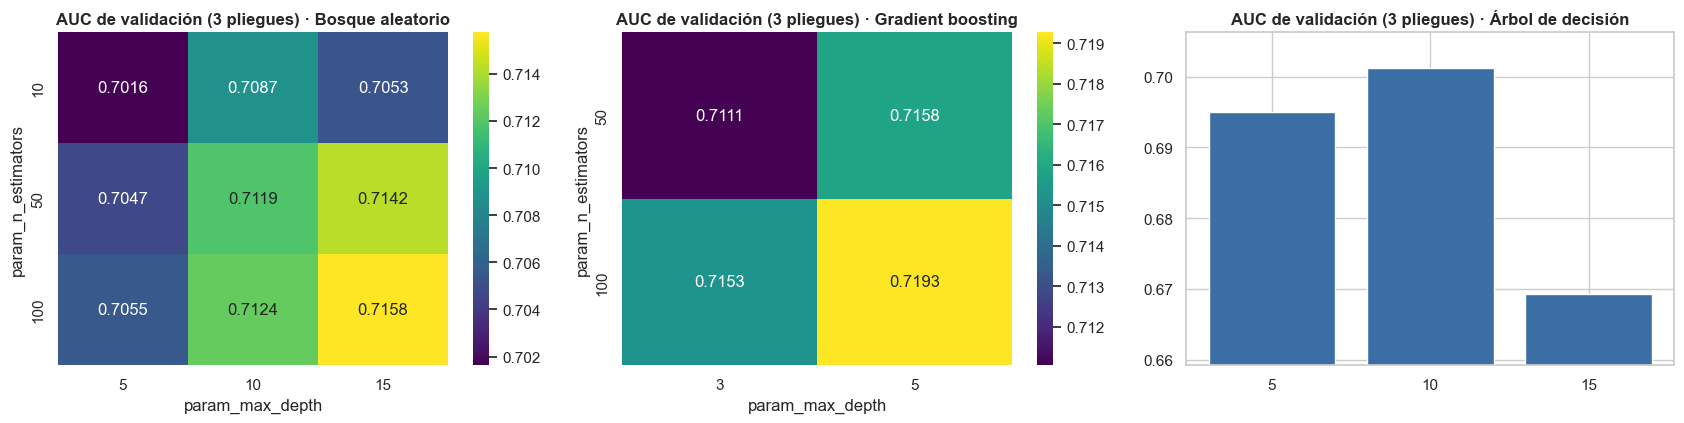

In [9]:
resumen = pd.DataFrame([{
    "modelo": r["modelo"], "mejores hiperparámetros": json.dumps(r["mejores_hiperparametros"]),
    "AUC CV": r["auc_cv"], "± sd (pliegues)": r["auc_cv_sd"], "AUC entrenamiento": r["auc_train_reajustado"],
    "brecha (train − CV)": r["auc_train_reajustado"] - r["auc_cv"],
    "tiempo entrenamiento + CV (s)": r["t_entrenamiento_con_cv_s"], "tiempo predicción test (s)": r["t_prediccion_s"]}
    for r in RES.values()]).set_index("modelo")
display(resumen)
resumen.to_csv(RESULTS / "sk_resumen_modelos.csv")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
for a, clave in zip(ax, ["RF", "GB", "DT"]):
    cv_ = pd.read_csv(RESULTS / f"sk_cv_{clave}.csv")
    pcols = [c for c in cv_.columns if c.startswith("param_")]
    if len(pcols) == 2:
        pv = cv_.pivot(index=pcols[1], columns=pcols[0], values="mean_test_score")
        sns.heatmap(pv, annot=True, fmt=".4f", cmap="viridis", ax=a)
    else:
        a.bar(cv_[pcols[0]].astype(str), cv_["mean_test_score"], color="#3b6ea5")
        a.set_ylim(cv_["mean_test_score"].min() - 0.01, cv_["mean_test_score"].max() + 0.005)
    a.set_title(f"AUC de validación (3 pliegues) · {lm.NOMBRES[clave]}")
plt.tight_layout()
plt.show()

### Comprobación: ¿filtra información el escalado fuera de la validación cruzada?

Para que ambos entornos partan de matrices idénticas, los transformadores (codificación *one-hot* con
agrupación de categorías infrecuentes y estandarización) se ajustan una sola vez con todo el
entrenamiento, antes de la validación cruzada. Para la regresión logística y la SVM lineal esto hace
que la media y la desviación de cada pliegue de validación entren en el escalado: una fuga leve, porque
son estadísticos sin la etiqueta. Para acotarla, se repite la búsqueda de la regresión logística con
`Pipeline`, que reajusta el escalador dentro de cada pliegue, y se compara.

In [10]:
t0 = time.time()
gs_pipe = GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=100, random_state=lc.SEED)),
                       {"logisticregression__C": specs["LR"][1]["C"]}, cv=FOLDS, scoring="roc_auc", n_jobs=-1).fit(X_train, y_train)
comp = pd.DataFrame({"AUC CV (mejor C)": [RES["LR"]["auc_cv"], gs_pipe.best_score_],
                     "mejor C": [RES["LR"]["mejores_hiperparametros"]["C"], gs_pipe.best_params_["logisticregression__C"]]},
                    index=["sin Pipeline (escalador con todo el entrenamiento)", "con Pipeline (escalador dentro de cada pliegue)"])
display(comp)
DIF_ESCALADO = float(RES["LR"]["auc_cv"] - gs_pipe.best_score_)
print(f"Diferencia de AUC CV = {DIF_ESCALADO:+.6f} (calculada en {time.time() - t0:.0f} s)")

,AUC CV (mejor C),mejor C
sin Pipeline (escalador con todo el entrenamiento),0.7096,0.9292
con Pipeline (escalador dentro de cada pliegue),0.7096,0.9292


Diferencia de AUC CV = -0.000000 (calculada en 13 s)


La diferencia de AUC es inferior a 10⁻⁶ y el hiperparámetro elegido es idéntico: con más de 700 000
filas por ajuste, la media y la desviación de un pliegue apenas cambian, y el escalado no filtra
información relevante sobre la etiqueta.

## 2.7 Evaluación en el conjunto de prueba

Se reportan **exactitud (*accuracy*), precisión, sensibilidad (*recall*), F1 y ROC AUC**, junto con la matriz
de confusión. Para las
métricas con umbral se muestran dos puntos de operación: el **por defecto** (0.5 para probabilidades,
0 para el valor de decisión de `LinearSVC`) y el **umbral que maximiza F1 en las puntuaciones fuera de
pliegue del entrenamiento** (no del conjunto de prueba).

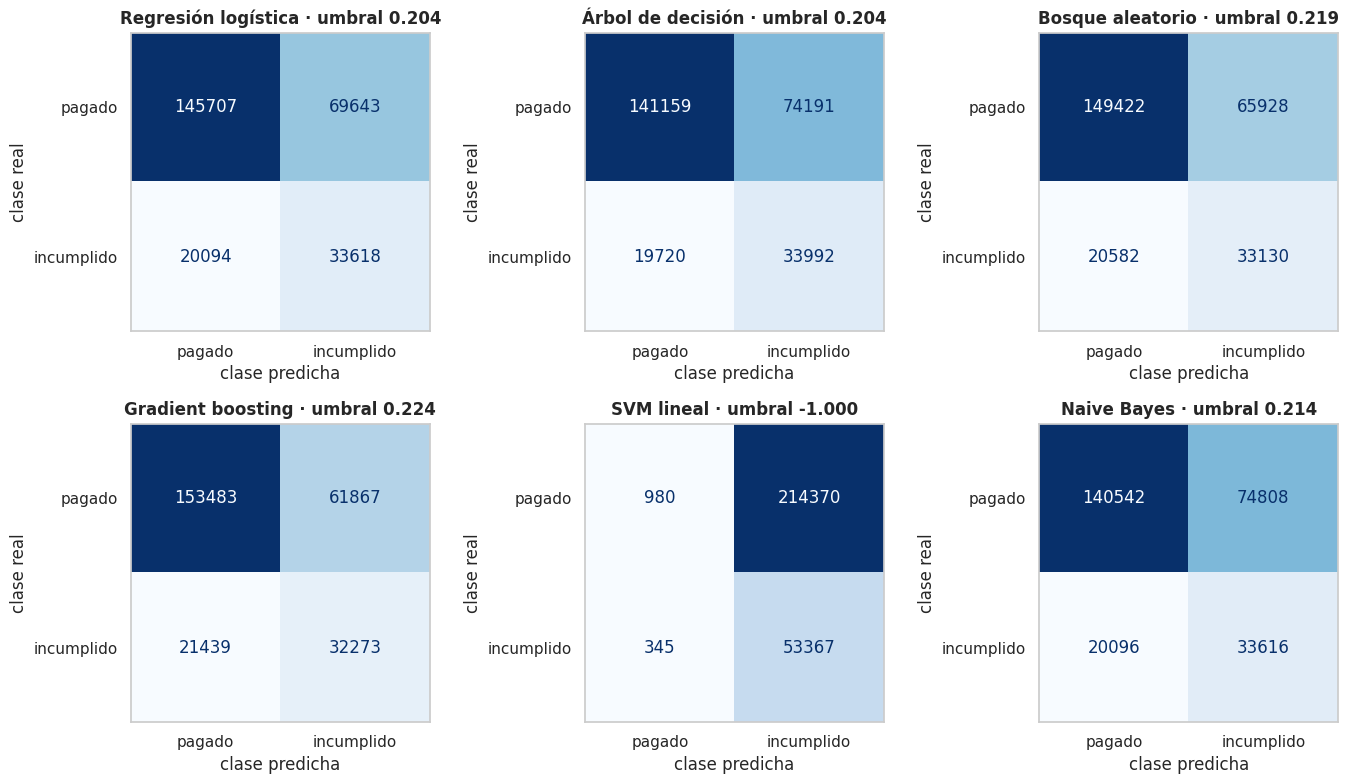

In [2]:
if "SCORES_TEST" not in globals():      # permite ejecutar esta celda sola, desde los resultados guardados
    _st = pd.read_parquet(RESULTS / "sk_scores_test.parquet")
    RES = json.loads((RESULTS / "sk_resultados.json").read_text(encoding="utf-8"))["modelos"]
    y_test = _st["y"].to_numpy()
    SCORES_TEST = {k: _st[k].to_numpy() for k in RES}
filas = []
for clave, r in RES.items():
    s = SCORES_TEST[clave]
    for nombre, thr in (("defecto", r["umbral_defecto"]), ("umbral F1 (OOF)", r["umbral_f1"])):
        mt = lc.threshold_metrics(y_test, s, thr)
        filas.append({"modelo": r["modelo"], "umbral usado": nombre, **mt, "ROC AUC": r["auc_test"],
                      "AUC-PR": average_precision_score(y_test, s)})
met = pd.DataFrame(filas).set_index(["modelo", "umbral usado"])
fmt = {c: "{:.4f}" for c in ["accuracy", "precision", "recall", "f1", "ROC AUC", "AUC-PR", "balanced_acc", "mcc", "especificidad"]}
fmt.update({"umbral": "{:.3f}", "TN": "{:,.0f}", "FP": "{:,.0f}", "FN": "{:,.0f}", "TP": "{:,.0f}"})
display(met[["umbral", "accuracy", "precision", "recall", "f1", "ROC AUC", "AUC-PR", "TN", "FP", "FN", "TP"]].style.format(fmt))
met.to_csv(RESULTS / "sk_metricas_test.csv")

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
for a, (clave, r) in zip(ax.ravel(), RES.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, (SCORES_TEST[clave] >= r["umbral_f1"]).astype(int),
                                            display_labels=["pagado", "incumplido"], cmap="Blues", ax=a,
                                            colorbar=False, values_format="d")
    a.set(xlabel="clase predicha", ylabel="clase real")
    a.set_title(f"{r['modelo']} · umbral {r['umbral_f1']:.3f}")
    a.grid(False)
plt.tight_layout()
plt.show()

Con el umbral por defecto la exactitud es alta pero la sensibilidad es muy baja en los
modelos que ordenan bien pero no cruzan 0.5 (la clase minoritaria rara vez supera esa probabilidad):
es el efecto del desbalance, y la razón por la que **la exactitud no sirve** como criterio aquí. Con el
umbral elegido en el entrenamiento cada modelo detecta una fracción mucho mayor de incumplimientos a
costa de más falsas alarmas.

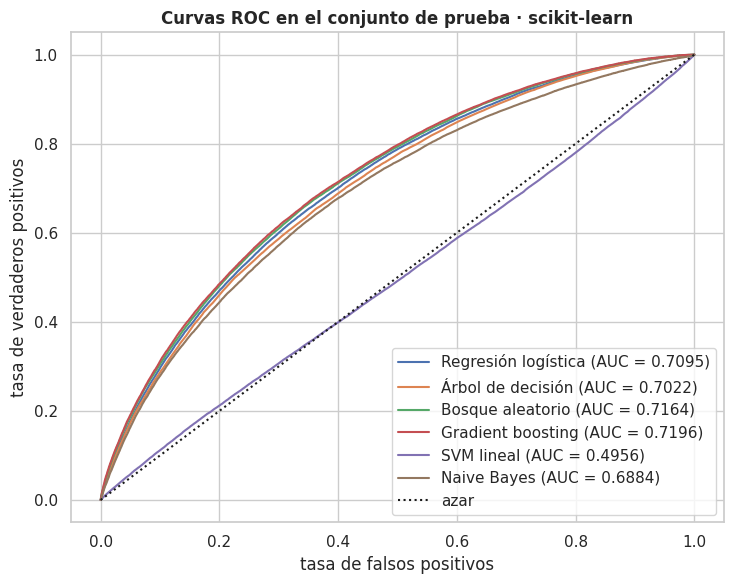

In [3]:
if "SCORES_TEST" not in globals():      # permite ejecutar esta celda sola, desde los resultados guardados
    _st = pd.read_parquet(RESULTS / "sk_scores_test.parquet")
    RES = json.loads((RESULTS / "sk_resultados.json").read_text(encoding="utf-8"))["modelos"]
    y_test = _st["y"].to_numpy()
    SCORES_TEST = {k: _st[k].to_numpy() for k in RES}
from sklearn.metrics import roc_curve  # noqa: E402

fig, ax = plt.subplots(figsize=(7.5, 6))
for clave, r in RES.items():
    fpr, tpr, _ = roc_curve(y_test, SCORES_TEST[clave])
    ax.plot(fpr, tpr, label=f"{r['modelo']} (AUC = {r['auc_test']:.4f})")
ax.plot([0, 1], [0, 1], "k:", label="azar")
ax.set(xlabel="tasa de falsos positivos", ylabel="tasa de verdaderos positivos")
ax.legend(loc="lower right")
ax.set_title("Curvas ROC en el conjunto de prueba · scikit-learn")
plt.tight_layout()
plt.show()

## 2.8 Guardar las puntuaciones del conjunto de prueba, los umbrales y los tiempos

Se guardan, para cada modelo, las puntuaciones continuas del conjunto de prueba junto con `id` y `default`
(`resultados/sk_scores_test.parquet`), que usará la prueba de DeLong, y las puntuaciones **fuera de
pliegue** del entrenamiento (`sk_scores_oof.parquet`) con las que se eligió cada umbral.

In [13]:
pd.DataFrame({"id": test["id"].to_numpy(), "y": y_test, **{k: v for k, v in SCORES_TEST.items()}}).to_parquet(
    RESULTS / "sk_scores_test.parquet", index=False)
pd.DataFrame({"id": train["id"].to_numpy(), "y": y_train, **{k: v for k, v in SCORES_OOF.items()}}).to_parquet(
    RESULTS / "sk_scores_oof.parquet", index=False)
ESTADO = {"modelos": RES, "tiempos_comunes_s": TIMES, "hilos": N_CPU, "ram_gb": psutil.virtual_memory().total / 1e9,
          "filas_train": int(N_TRAIN), "filas_test": int(len(y_test)), "n_features_modelo": int(X_train.shape[1]),
          "gb_hist": GB_HIST, "sklearn": sklearn.__version__, "dif_escalado_auc_cv": DIF_ESCALADO}
(RESULTS / "sk_resultados.json").write_text(json.dumps(ESTADO, indent=1, default=float), encoding="utf-8")
print("Guardado:", sorted(p.name for p in RESULTS.glob("sk_*")))

Guardado: ['sk_cv_DT.csv', 'sk_cv_GB.csv', 'sk_cv_LR.csv', 'sk_cv_RF.csv', 'sk_cv_SVM.csv', 'sk_metricas_test.csv', 'sk_resultados.json', 'sk_resumen_modelos.csv', 'sk_scores_oof.parquet', 'sk_scores_test.parquet']


## 2.9 Validación temporal complementaria (bosque aleatorio)

La partición aleatoria mezcla épocas: el modelo "conoce" el futuro (préstamos posteriores a los que
predice). En la práctica un modelo de crédito se entrena con el pasado y se usa en el futuro. Para
medir cuánto optimismo introduce la partición aleatoria, se entrena con préstamos **≤ 2014** y se
evalúa con los de **2015**, en plazo de **36 meses** (los de 36 meses otorgados en 2015 vencían a más tardar a finales
de 2018, así que la censura vista en el EDA es mínima). Se comparan **las mismas filas** de prueba con el modelo de la
partición aleatoria (bosque con los mejores hiperparámetros de 2.5).

In [14]:
rf_best = BEST["RF"]
tr_t = train[(train["issue_year"] <= 2014) & (train["term_months"] == 36)]
te_t = test[(test["issue_year"] == 2015) & (test["term_months"] == 36)]
prep_t = lc.make_preprocessor()
Xt_tr = prep_t.fit_transform(tr_t[lc.FEATURES]).astype(np.float32)
Xt_te = prep_t.transform(te_t[lc.FEATURES]).astype(np.float32)
rf_t = RandomForestClassifier(**{**rf_best.get_params(deep=False), "n_jobs": -1}).fit(Xt_tr, tr_t["default"])
auc_temporal = roc_auc_score(te_t["default"], rf_t.predict_proba(Xt_te)[:, 1])
p_rand = rf_best.predict_proba(prep.transform(te_t[lc.FEATURES]).astype(np.float32))[:, 1]
auc_random_mismas = roc_auc_score(te_t["default"], p_rand)
display(pd.DataFrame({"AUC en préstamos de 2015 (36 m)": [auc_random_mismas, auc_temporal],
                      "entrenó con": ["partición aleatoria (todos los años, incl. 2015 y posteriores)", "solo 2007–2014"]},
                     index=["Modelo de la partición aleatoria", "Modelo temporal (pasado → futuro)"]))
print(f"Filas de entrenamiento temporal: {len(tr_t):,} · filas de prueba (2015, 36 m): {len(te_t):,} · "
      f"diferencia de AUC = {auc_random_mismas - auc_temporal:+.4f}")
ESTADO["auc_temporal_2015_36m"], ESTADO["auc_aleatorio_mismas_filas"] = float(auc_temporal), float(auc_random_mismas)
del tr_t, Xt_tr, Xt_te, rf_t
gc.collect()

,AUC en préstamos de 2015 (36 m),entrenó con
Modelo de la partición aleatoria,0.6977,"partición aleatoria (todos los años, incl. 201..."
Modelo temporal (pasado → futuro),0.6884,solo 2007–2014


Filas de entrenamiento temporal: 268,455 · filas de prueba (2015, 36 m): 56,626 · diferencia de AUC = +0.0093


14930

La diferencia entre las dos filas es el **optimismo** de validar de forma aleatoria en
datos con orden temporal. El AUC que mejor anticipa el desempeño futuro es el temporal, que suele ser
algo menor.

```{note}
Esta comparación mezcla tres factores a la vez: el optimismo temporal, un tamaño de entrenamiento
distinto (1.08 millones de filas en el modelo aleatorio frente a 268 455 en el temporal, todas a 36
meses) y una composición de datos distinta. Por eso la diferencia no mide el optimismo temporal de forma aislada:
el mayor tamaño del modelo aleatorio tiende a agrandarla y la composición más homogénea del temporal
podría reducirla. Además, es una sola partición temporal y se reporta sin intervalo de confianza.
```

## 2.10 Importancia de variables (bosque aleatorio)

La importancia por **permutación** mide cuánto cae el AUC al barajar una variable (sobre 50 000 filas
de prueba, solo por costo; es una herramienta de **interpretación**, no se usa para elegir nada).

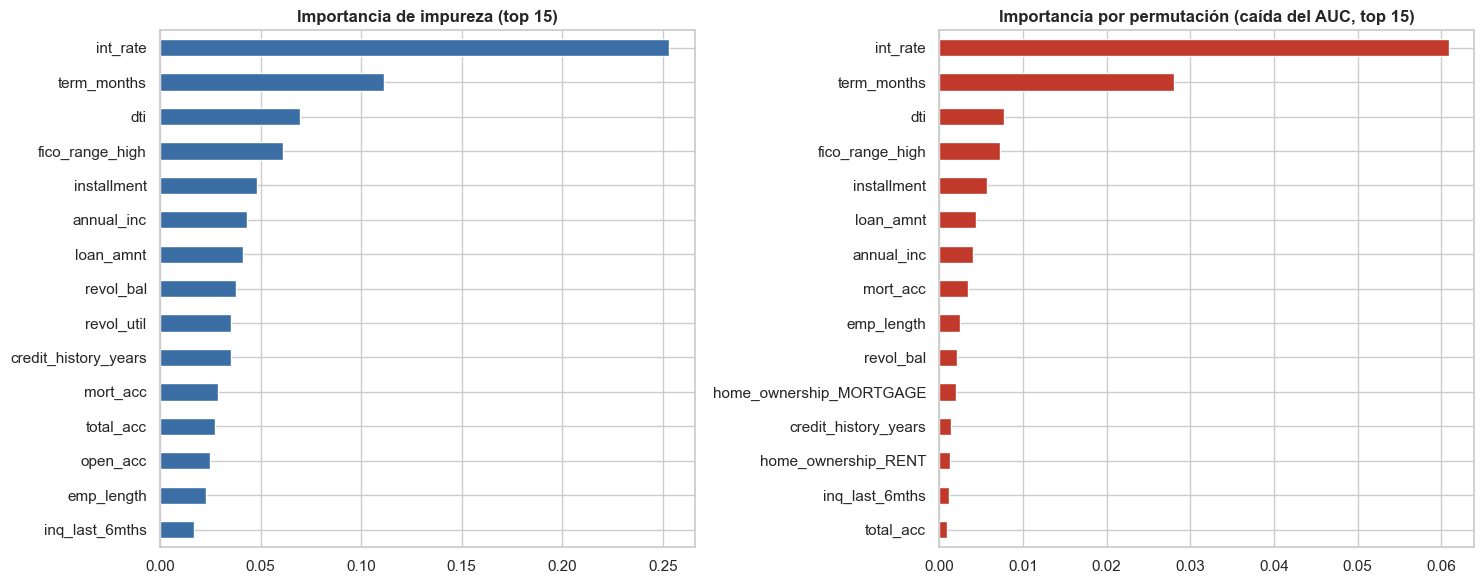

In [15]:
imp_imp = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)
sub = np.random.default_rng(lc.SEED).choice(len(y_test), 50000, replace=False)
pi = permutation_importance(rf_best, X_test[sub], y_test[sub], scoring="roc_auc", n_repeats=3, random_state=lc.SEED, n_jobs=-1)
imp_perm = pd.Series(pi.importances_mean, index=feature_names).sort_values(ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
imp_imp.head(15).iloc[::-1].plot.barh(ax=ax[0], color="#3b6ea5")
ax[0].set(title="Importancia de impureza (top 15)")
imp_perm.head(15).iloc[::-1].plot.barh(ax=ax[1], color="#c0392b")
ax[1].set(title="Importancia por permutación (caída del AUC, top 15)")
plt.tight_layout()
plt.show()

## 2.11 Latencia de predicción del mejor modelo con probabilidades (para LIME)

LIME se aplica al modelo de **mayor AUC de cada entorno entre los que entregan probabilidades**
(`LinearSVC` no las produce). Necesita evaluar el modelo miles de veces sobre datos perturbados;
se mide cuánto tarda `predict_proba` según el tamaño del lote.

In [16]:
prob = {k: r["auc_test"] for k, r in RES.items() if r["tipo_puntuacion"] == "proba"}
LIME_CLAVE = max(prob, key=prob.get)
print(f"Mejor modelo con probabilidades (AUC en test): {lm.NOMBRES[LIME_CLAVE]} = {prob[LIME_CLAVE]:.4f}")
mejor = BEST[LIME_CLAVE]
Xl = X_test if not lm.USA_ESCALADO.get(LIME_CLAVE) else Xs_test
lat = {}
for n in (1, 100, 5000):
    ts = []
    for _ in range(5):
        t0 = time.perf_counter()
        mejor.predict_proba(Xl[:n])
        ts.append(time.perf_counter() - t0)
    lat[n] = float(np.median(ts))
print({k: f"{v * 1000:.1f} ms" for k, v in lat.items()})
ESTADO["lime_modelo"] = LIME_CLAVE
ESTADO["latencia_predict_s"] = {str(k): v for k, v in lat.items()}

Mejor modelo con probabilidades (AUC en test): Gradient boosting = 0.7196
{1: '0.2 ms', 100: '0.6 ms', 5000: '13.5 ms'}


## 2.12 Experimento de escala: ¿cuánto tarda un bosque según el volumen?

Se ajusta **un bosque fijo** (50 árboles, profundidad 10, `n_jobs=-1`) con subconjuntos crecientes del
entrenamiento (las filas con `rank` < N, el mismo orden aleatorio que usará PySpark) y se mide el tiempo.
Es un *benchmark* de tiempos, por eso aquí sí hay submuestras; los modelos principales se entrenan
con todo el conjunto de entrenamiento.

In [17]:
rank_train = split.loc[~es_test, "rank"].to_numpy()
esc = []
for n in [10_000, 50_000, 100_000, 250_000, 500_000, N_TRAIN]:
    sel = rank_train < n
    t0 = time.time()
    rf_e = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=lc.SEED, n_jobs=-1).fit(X_train[sel], y_train[sel])
    t_fit = time.time() - t0
    a = roc_auc_score(y_test, rf_e.predict_proba(X_test)[:, 1])
    esc.append({"filas_train": int(sel.sum()), "t_ajuste_s": t_fit, "auc_test": a})
    print(f"{int(sel.sum()):>10,} filas · ajuste {t_fit:6.1f} s · AUC {a:.4f}", flush=True)
pd.DataFrame(esc).to_csv(RESULTS / "escala_sklearn.csv", index=False)

    10,000 filas · ajuste    0.3 s · AUC 0.7012


    50,000 filas · ajuste    0.7 s · AUC 0.7086


   100,000 filas · ajuste    1.2 s · AUC 0.7101


   250,000 filas · ajuste    3.3 s · AUC 0.7113


   500,000 filas · ajuste    6.9 s · AUC 0.7114


 1,076,248 filas · ajuste   16.2 s · AUC 0.7114


## 2.13 Guardar los artefactos para los siguientes capítulos

In [18]:
ESTADO["tiempo_total_modelos_s"] = float(sum(r["t_entrenamiento_con_cv_s"] + r["t_prediccion_s"] for r in RES.values()))
(RESULTS / "sk_resultados.json").write_text(json.dumps(ESTADO, indent=1, default=float), encoding="utf-8")
joblib.dump({"prep": prep, "scaler": scaler if lm.USA_ESCALADO.get(LIME_CLAVE) else None, "model": BEST[LIME_CLAVE],
             "clave": LIME_CLAVE, "threshold": RES[LIME_CLAVE]["umbral_f1"]}, DATA_DIR / "models" / "sk_lime_model.joblib")
joblib.dump(BEST["RF"], DATA_DIR / "models" / "sk_rf.joblib")
print("Artefactos guardados en data/models/ · tiempo total de entrenamiento+predicción de los seis modelos: "
      f"{ESTADO['tiempo_total_modelos_s'] / 60:.1f} min")

Artefactos guardados en data/models/ · tiempo total de entrenamiento+predicción de los seis modelos: 80.2 min
